Gini-Index für einen 
Entscheidungsbaum berechnen

In [2]:
# Datensatz
# Gegeben ist folgender Datensatz:

# ID Alter Einkommen Kauf
# 1 Jung Hoch Nein
# 2 Jung Hoch Nein
# 3 Mittel Hoch Ja
# 4 Alt Mittel Ja
# 5 Alt Niedrig Ja
# 6 Alt Niedrig Nein
# 7 Mittel Niedrig Ja
# 8 Jung Mittel Nein

# Zielvariable:
# Kauf = Ja oder Nein

In [3]:
import pandas as pd

In [4]:
df = pd.DataFrame()
df['ID'] = range(1,9,1)
df['Alter'] = ['Jung','Jung', 'Mittel', 'Alt', 'Alt', 'Alt', 'Mittel','Jung']
df['Einkommen'] = ['Hoch', 'Hoch', 'Hoch','Mittel', 'Niedrig', 'Niedrig', 'Niedrig','Mittel']
df['Kauf'] = ["Nein","Nein", "Ja", "Ja", "Ja", "Nein", "Ja", "Nein"]
print(df)

   ID   Alter Einkommen  Kauf
0   1    Jung      Hoch  Nein
1   2    Jung      Hoch  Nein
2   3  Mittel      Hoch    Ja
3   4     Alt    Mittel    Ja
4   5     Alt   Niedrig    Ja
5   6     Alt   Niedrig  Nein
6   7  Mittel   Niedrig    Ja
7   8    Jung    Mittel  Nein


Aufgabe 1

In [5]:
#Schreibe eine Python-Funktion:
# def gini(labels):
#Die Funktion soll den Gini-Index einer Liste von Klassenlabels berechnen.
#Beispiel:
#labels = ["Ja","Ja","Nein","Nein"]
#Erwartetes Ergebnis:
#0.5


def gini(labels):   #bekommt eine Liste als Argument

    # probs = labels.value_counts(normalize = True)   #VIEL EINFACHER!!!!!
    # return 1-(probs **2).sum()

    l = len(labels)  #Anzahl der values
    faelle = list(set(labels)) #unique values in die Liste labels
    p = {}   # Dictionary für Wahrscheinlichkeiten von Fällen 
    sumPquadrat = 0
    for f in faelle:
        p[f]=labels.count(f)/l
        sumPquadrat+=p[f]**2
    gini= 1-sumPquadrat
    # print(f'Wahrscheinlichkeiten {p}')
    return gini

labels = ["Ja","Ja","Nein","Nein"]
print(gini(labels))

0.5


Aufgabe 2

Berechne den Gini-Index des gesamten Datensatzes.



Tipp:
Kauf = [Nein, Nein, Ja, Ja, Ja, Nein, Ja, Nein]

In [6]:
#Kauf = ["Nein","Nein", "Ja", "Ja", "Ja", "Nein", "Ja", "Nein"]
print(gini(df['Kauf'].tolist()))


0.5


Aufgabe 3

In [7]:
# Schreibe eine Funktion:
# def split_dataset(data, feature):
# Diese Funktion soll:
# • einen Datensatz nach einem Feature aufteilen
# • Teilgruppen zurückgeben
# Beispiel:
# feature = "Alter"
# Output:
# {
# "Jung": [...],
# "Mittel": [...],
# "Alt": [...]
# }

In [ ]:
def split_dataset(data, feature):

    # groups = df.groupby(feature)   # EINFACHER!!!
    # for name, group in groups:
    #     print(name)
    #     print(group)


    gruppen = data[feature].unique()
    split_data = {}
    for g in gruppen:
        split_data[g]=data[data[feature]==g].drop(columns=[feature])
    return split_data
    print(gruppen)

split_dataset(df,'Alter')
# print(split_dataset(df,'Alter'))

Alt
   ID Alter Einkommen  Kauf
3   4   Alt    Mittel    Ja
4   5   Alt   Niedrig    Ja
5   6   Alt   Niedrig  Nein
Jung
   ID Alter Einkommen  Kauf
0   1  Jung      Hoch  Nein
1   2  Jung      Hoch  Nein
7   8  Jung    Mittel  Nein
Mittel
   ID   Alter Einkommen Kauf
2   3  Mittel      Hoch   Ja
6   7  Mittel   Niedrig   Ja


{'Jung':    ID Einkommen  Kauf
 0   1      Hoch  Nein
 1   2      Hoch  Nein
 7   8    Mittel  Nein,
 'Mittel':    ID Einkommen Kauf
 2   3      Hoch   Ja
 6   7   Niedrig   Ja,
 'Alt':    ID Einkommen  Kauf
 3   4    Mittel    Ja
 4   5   Niedrig    Ja
 5   6   Niedrig  Nein}

Aufgabe 4

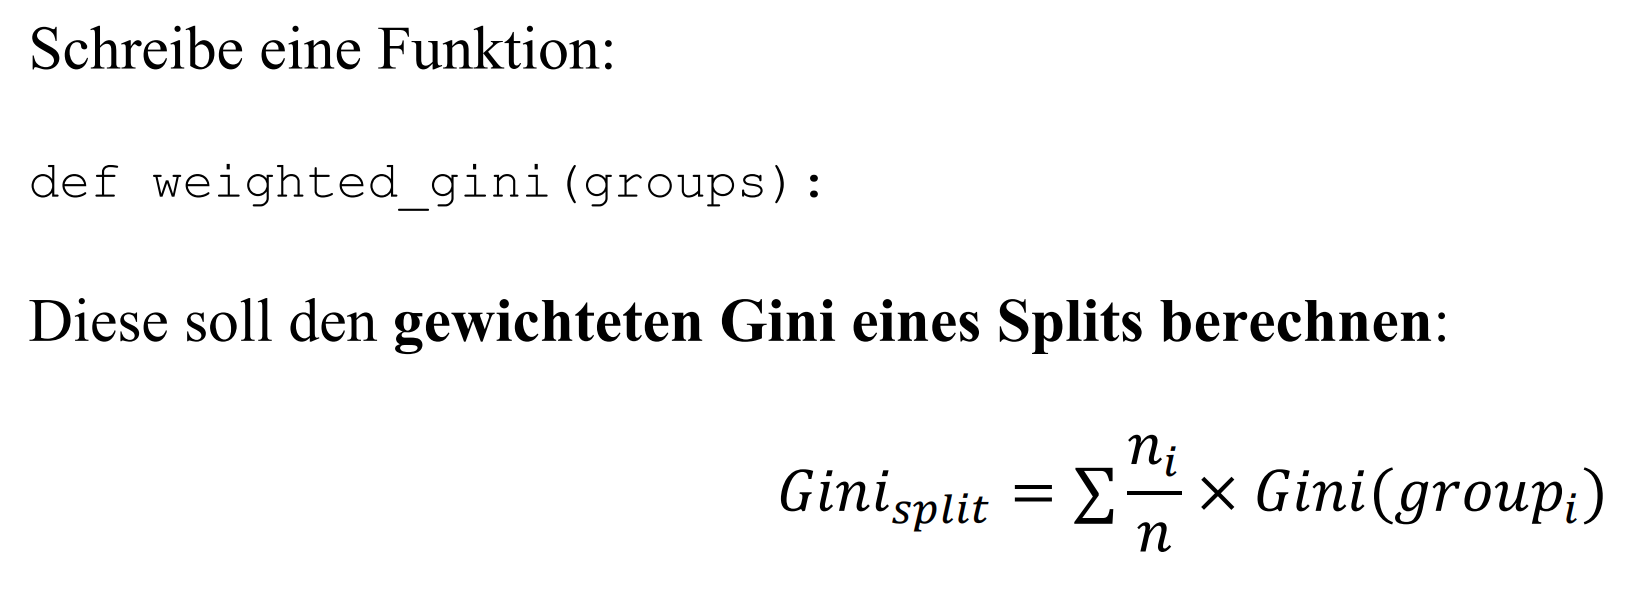

In [17]:
def weighted_gini(groups):
    gini_split = 0
    pGini = []
    gesamte_Anzahl=0
    for g in groups:   #für keys in Dictionary
        pGini.append([len(groups[g]),gini(groups[g]['Kauf'].tolist())]) #Kauf wie target spalte
        #wie schreibe ich universel, ohne 'Kauf'?
        gesamte_Anzahl+=len(groups[g])
    # print(pGini, gesamte_Anzahl)
    for i in pGini:
        gini_split += (i[0]/gesamte_Anzahl)*i[1]
    
    return gini_split 
        

groups = split_dataset(df,'Alter')
weighted_gini(groups)

Alt
   ID Alter Einkommen  Kauf
3   4   Alt    Mittel    Ja
4   5   Alt   Niedrig    Ja
5   6   Alt   Niedrig  Nein
Jung
   ID Alter Einkommen  Kauf
0   1  Jung      Hoch  Nein
1   2  Jung      Hoch  Nein
7   8  Jung    Mittel  Nein
Mittel
   ID   Alter Einkommen Kauf
2   3  Mittel      Hoch   Ja
6   7  Mittel   Niedrig   Ja


0.16666666666666666

Aufgabe 5

In [10]:
# Berechne den Gini-Split für jedes Feature:
# Alter
# Einkommen

# Bestimme:
# Welches Feature ist der beste Split?

In [11]:
group1 = split_dataset(df,'Alter')
giniAlter = round(weighted_gini(group1),3)

group2 = split_dataset(df,'Einkommen')
giniEinkommen = round(weighted_gini(group2),3)

print(f'giniAlter = {giniAlter}\n giniEinkommen = {giniEinkommen}')
# je kleiner gini desto besser

giniAlter = 0.167
 giniEinkommen = 0.458


Aufgabe 6 (Bonus – Mini Decision Tree)

In [12]:
# Schreibe eine Funktion:
# def best_split(data):
# Die Funktion soll:
# 1. alle Features testen
# 2. den Gini-Split berechnen
# 3. das Feature mit dem kleinsten Gini zurückgeben

In [ ]:
#!!!! Ohne ID!!!
def best_split(data):
    featureGini = []
    for c in data.columns.drop("Kauf"):
        groups = split_dataset(data,c)
        featureGini.append([c,round(weighted_gini(groups),3)])
    minGini = min(featureGini, key=lambda x: x[1]) #Verglieche nur 2.Element in jeder kleinen Array 
    # print(min_gini)
    return minGini
best_split(df)

Alt
   ID Alter Einkommen  Kauf
3   4   Alt    Mittel    Ja
4   5   Alt   Niedrig    Ja
5   6   Alt   Niedrig  Nein
Jung
   ID Alter Einkommen  Kauf
0   1  Jung      Hoch  Nein
1   2  Jung      Hoch  Nein
7   8  Jung    Mittel  Nein
Mittel
   ID   Alter Einkommen Kauf
2   3  Mittel      Hoch   Ja
6   7  Mittel   Niedrig   Ja
Alt
   ID Alter Einkommen  Kauf
3   4   Alt    Mittel    Ja
4   5   Alt   Niedrig    Ja
5   6   Alt   Niedrig  Nein
Jung
   ID Alter Einkommen  Kauf
0   1  Jung      Hoch  Nein
1   2  Jung      Hoch  Nein
7   8  Jung    Mittel  Nein
Mittel
   ID   Alter Einkommen Kauf
2   3  Mittel      Hoch   Ja
6   7  Mittel   Niedrig   Ja
Alt
   ID Alter Einkommen  Kauf
3   4   Alt    Mittel    Ja
4   5   Alt   Niedrig    Ja
5   6   Alt   Niedrig  Nein
Jung
   ID Alter Einkommen  Kauf
0   1  Jung      Hoch  Nein
1   2  Jung      Hoch  Nein
7   8  Jung    Mittel  Nein
Mittel
   ID   Alter Einkommen Kauf
2   3  Mittel      Hoch   Ja
6   7  Mittel   Niedrig   Ja


['ID', 0.0]